<a href="https://colab.research.google.com/github/Eng-NadeenShadeed/BinX_AI_ML_Internship/blob/main/Week7/Day%202/Hands_On_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# @title
from google.colab import drive
drive.mount('/content/drive')
import os

os.chdir('/content/drive/MyDrive/BinX_AI_ML_Internship/Week7/Day 2')
print("Ready ✓")
print("Files:", os.listdir('.'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ready ✓
Files: ['day2_cnn_transfer_learning.ipynb', 'Hands_On_Lab']


# Week 7 · Day 2 — Hands-On Lab: Building CNNs & Transfer Learning
**BinX Tech — AI & ML Internship**

Melanoma Skin Cancer Classification — Benign vs Malignant

## Objective

This lab trains and compares three approaches for Melanoma Skin Cancer classification:

1. **CNN from Scratch** — a baseline CNN trained without data augmentation.
2. **CNN + Data Augmentation** — the same CNN architecture trained with augmented images.
3. **Transfer Learning with MobileNetV2** — a pretrained CNN used as a frozen feature extractor.

For each approach, I will examine the training process, validation performance, and final test performance.

At the end of the lab, I will compare the three approaches and document which model performed best and why.

**Dataset:** Melanoma dermoscopic images
**Task:** Binary classification — Benign (0) vs Malignant (1)
**Hardware:** Google Colab GPU


---

## Step 1 — Import Libraries

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    RandomFlip, RandomRotation, RandomZoom, RandomBrightness,
    GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 2 — Load Dataset

### The Plan
I need to split 11,888 images into three sets. I chose 70/15/15 because:
- The dataset is medium-sized — the model needs as many training images as possible
- 15% validation (~1,783 images) is enough to reliably detect overfitting
- 15% test (~1,783 images) is enough to give a trustworthy final evaluation

A 60/20/20 split would give the model 1,189 fewer training images for no real gain
in evaluation reliability — so 70/15/15 is the better trade-off here.

### Why Batches?
The GPU cannot load 8,322 images at once — memory is limited. I split training
into batches of 32 images. The model trains on one batch, updates its weights,
then moves to the next. One full pass through all batches = one epoch.

**Batch size = 32:** a standard choice that balances training speed,
learning quality, and GPU memory usage.

### Why cache() and prefetch()?
Images are stored on Drive — loading them every epoch is slow.
- `cache()` stores images in memory after the first load
- `prefetch()` prepares the next batch while the GPU trains on the current one

This keeps the GPU busy and cuts training time significantly.

In [8]:
from google.colab import drive
drive.mount('/content/drive')
import os, shutil

# نسخ الصور للـ local storage
if os.path.exists('/content/train'):
    shutil.rmtree('/content/train')

shutil.copytree(
    '/content/drive/MyDrive/BinX_AI_ML_Internship/Week7/Day 1/Data/train',
    '/content/train'
)

print("Done! ✓")
print(os.listdir('/content/train'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Done! ✓
['Malignant', 'Benign']


In [9]:
# Paths
DATA_DIR  = '/content/train'
IMG_SIZE  = (128, 128)
BATCH     = 32
SEED      = 42

# Training set (70%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    label_mode="binary"
)

# Remaining 30% → split into val (15%) and test (15%)
val_test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    label_mode="binary"
)

# Split val_test equally
val_batches  = tf.data.experimental.cardinality(val_test_ds) // 2
val_ds       = val_test_ds.take(val_batches)
test_ds      = val_test_ds.skip(val_batches)

# Performance optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

# Class names
class_names = ["Benign", "Malignant"]

print("Classes:", class_names)
print(f"Training batches  : {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Validation batches: {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"Test batches      : {tf.data.experimental.cardinality(test_ds).numpy()}")

Found 11888 files belonging to 2 classes.
Using 8322 files for training.
Found 11888 files belonging to 2 classes.
Using 3566 files for validation.
Classes: ['Benign', 'Malignant']
Training batches  : 261
Validation batches: 56
Test batches      : 56


### What the Output Means

| Split | Batches | Images (approx) |
|-------|---------|-----------------|
| Training | 261 | 8,322 |
| Validation | 56 | 1,783 |
| Test | 56 | 1,783 |

261 training batches × 32 images = 8,352 ≈ 8,322 images.
The small difference is because the last batch may have fewer than 32 images.

The data is loaded, split, cached, and ready for training.
Next: I look at sample images to understand what the network will be learning from.

---

In [19]:
# @title
import shutil
import os

shutil.rmtree('/content/train')

shutil.copytree(
    '/content/drive/MyDrive/BinX_AI_ML_Internship/Week7/Day 1/Data/train',
    '/content/train'
)

print("Done! ✓")
print(os.listdir('/content/train'))

Done! ✓
['Malignant', 'Benign']


## Step 3 — Explore the Dataset

### Why look at the images before training?

Before building any model, I need to understand what the data looks like.
This step answers three questions:

- **What do benign and malignant lesions look like visually?**
  If the difference is subtle even to the human eye, the model will need
  deep features to separate them — which is exactly why transfer learning exists.

- **Is the data quality good?**
  Blurry, dark, or incorrectly labeled images hurt training.
  Spotting quality issues early saves time later.

- **What is the pixel value range?**
  Knowing whether pixels are in 0-255 or 0-1 range determines
  whether I need to normalize before training.

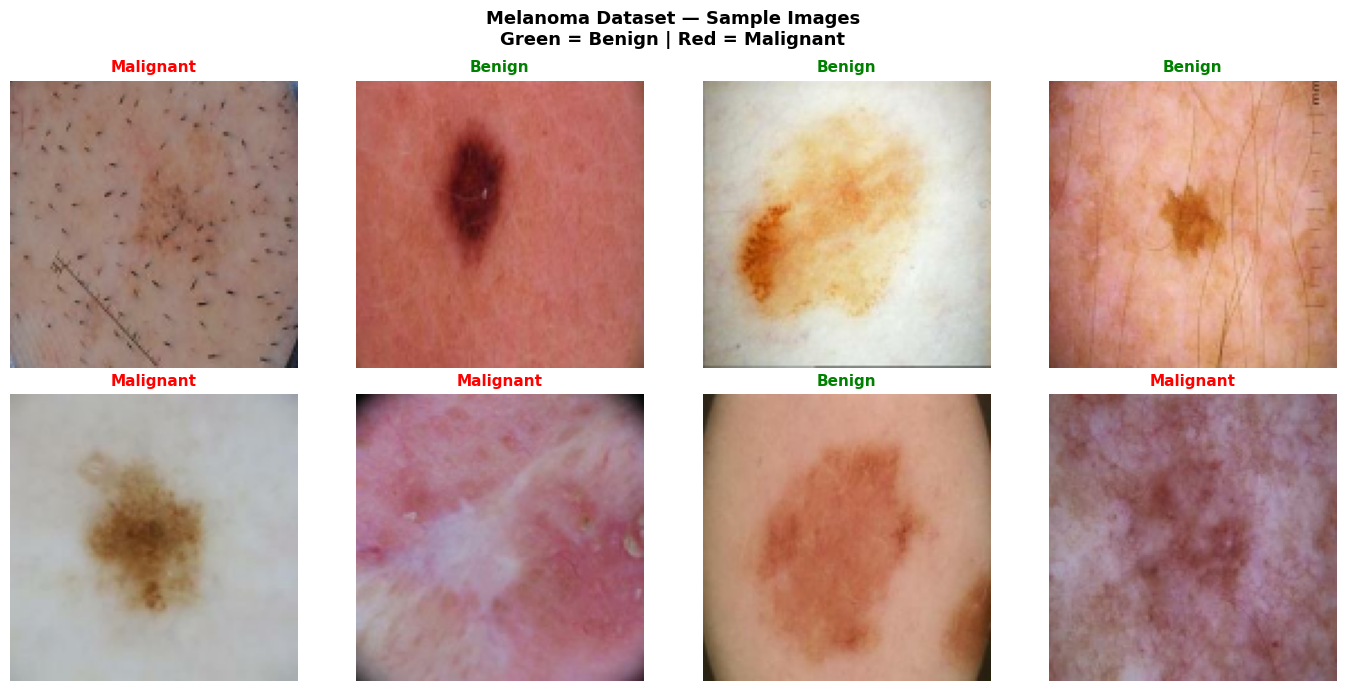

Image Statistics
Image shape  : (128, 128, 3)
Pixel range  : 0 → 255
Mean pixel   : 147.6
Std pixel    : 54.4


In [11]:
plt.figure(figsize=(14, 7))
plt.suptitle("Melanoma Dataset — Sample Images\nGreen = Benign | Red = Malignant",
             fontsize=13, fontweight="bold")

images, labels = next(iter(train_ds))

shown = {"Benign": 0, "Malignant": 0}
plot_idx = 1

for i in range(len(labels)):
    label_name = class_names[int(labels[i].numpy())]
    if shown[label_name] < 4:
        plt.subplot(2, 4, plot_idx)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(label_name, fontsize=11,
                  color="green" if label_name == "Benign" else "red",
                  fontweight="bold")
        plt.axis("off")
        shown[label_name] += 1
        plot_idx += 1
    if plot_idx > 8:
        break

plt.tight_layout()
plt.show()

print("Image Statistics")
print("=" * 40)
print(f"Image shape  : {images[0].numpy().shape}")
print(f"Pixel range  : {images.numpy().min():.0f} → {images.numpy().max():.0f}")
print(f"Mean pixel   : {images.numpy().mean():.1f}")
print(f"Std pixel    : {images.numpy().std():.1f}")

### What the Images Tell Us

**Malignant lesions:** irregular shapes, uneven dark colors (black, dark brown),
unclear and jagged borders, sometimes multiple colors within the same lesion.

**Benign lesions:** uniform color (light brown, pink), clear and regular borders,
symmetrical oval or circular shapes, generally smaller.

The visual difference exists but is not always obvious — some benign lesions
resemble malignant ones. This means the CNN cannot rely on simple color or
shape rules. It needs to learn deep, subtle features — which is exactly
why transfer learning from a model pretrained on millions of images will
outperform a CNN trained from scratch on 8,322 images.

**Pixel range: 0 → 255**
Images are not yet normalized. Neural networks train better when input values
are small (0 → 1). I will divide by 255 during training using a Rescaling layer
inside the model — so the raw images stay as-is and normalization happens
automatically during each forward pass.

## Step 4 — CNN from Scratch (Baseline)

### Why start with a CNN from scratch?

Before using advanced techniques such as data augmentation or transfer learning, I first establish a **baseline**.

The baseline is a CNN trained directly on the Melanoma images without data augmentation and without pretrained weights. Its purpose is to answer a fundamental question:

**How well can a basic CNN learn from the available training images on its own?**

The result of this model becomes my reference point. In the following steps, I will compare the augmented CNN and the transfer learning model against this baseline to determine whether these techniques actually improve performance.

### Architecture

The CNN consists of three convolutional and pooling blocks:

* **Conv2D (32 filters) → MaxPooling** — learns simple visual patterns such as edges.
* **Conv2D (64 filters) → MaxPooling** — combines simpler features into more complex patterns.
* **Conv2D (128 filters) → MaxPooling** — learns deeper and more complex visual features.

After the convolutional blocks, **Flatten** converts the feature maps into a one-dimensional vector. A **Dense** layer then uses these extracted features for classification.

**Dropout(0.5)** is added after the Dense layer to help reduce overfitting during training.

The final **Dense(1) with Sigmoid** produces a probability between 0 and 1 for the binary classification task:

* **0 → Benign**
* **1 → Malignant**

### Input Normalization

The images initially contain pixel values between 0 and 255. The `Rescaling(1./255)` layer automatically converts these values to the range 0–1 before they enter the CNN.

### Training Configuration

The model uses:

* **Adam** as the optimizer to update the network weights.
* **Binary Crossentropy** as the loss function for binary classification.
* **Accuracy** to measure the percentage of correct predictions.
* **AUC** to measure how well the model separates the two classes across different classification thresholds.

During training, callbacks such as **EarlyStopping** and **ReduceLROnPlateau** can be used to control the training process, reduce unnecessary training, and help limit overfitting.


In [12]:
from tensorflow.keras.layers import Rescaling

def build_cnn_scratch(input_shape=(128, 128, 3)):
    model = Sequential([
        # Normalization — pixels 0-255 → 0-1
        Rescaling(1./255, input_shape=input_shape),

        # Block 1
        Conv2D(32, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),

        # Block 2
        Conv2D(64, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),

        # Block 3
        Conv2D(128, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),

        # Classification head
        Flatten(),
        Dense(64, activation="relu"),
        Dropout(0.5),
        Dense(1, activation="sigmoid")
    ], name="CNN_Scratch")
    return model

cnn_scratch = build_cnn_scratch()

cnn_scratch.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

cnn_scratch.summary()

Model: "CNN_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,190,529 (8.36 MB)

 Trainable params: 2,190,529 (8.36 MB)

 Non-trainable params: 0 (0.00 B)

### Reading the Model Summary

The model summary shows how the image changes as it passes through each layer of the CNN.

| Layer        | Output Shape     | What happened                                                                |
| ------------ | ---------------- | ---------------------------------------------------------------------------- |
| Rescaling    | `(128, 128, 3)`  | Pixel values are scaled from 0–255 to 0–1                                    |
| Conv2D (32)  | `(128, 128, 32)` | 32 filters learn different visual patterns                                   |
| MaxPooling   | `(64, 64, 32)`   | Spatial dimensions are reduced by half while keeping strong signals          |
| Conv2D (64)  | `(64, 64, 64)`   | 64 filters learn more complex features from the previous layer               |
| MaxPooling   | `(32, 32, 64)`   | Spatial dimensions are reduced again                                         |
| Conv2D (128) | `(32, 32, 128)`  | 128 filters learn deeper and more complex visual features                    |
| MaxPooling   | `(16, 16, 128)`  | Spatial dimensions are reduced again                                         |
| Flatten      | `(32,768)`       | `16 × 16 × 128 = 32,768` values are converted into a 1D vector               |
| Dense (64)   | `(64)`           | Combines the extracted features for classification                           |
| Dropout      | `(64)`           | Randomly drops 50% of the neurons during training to help reduce overfitting |
| Dense (1)    | `(1)`            | Produces one probability for the binary classification: Benign or Malignant  |

### Parameter Breakdown

| Part                 |    Parameters | Role                                                 |
| -------------------- | ------------: | ---------------------------------------------------- |
| Convolutional blocks |        93,248 | Learn visual features and patterns                   |
| Dense layer          |     2,097,216 | Connects the 32,768 flattened features to 64 neurons |
| Output layer         |            65 | Produces the final binary classification probability |
| **Total**            | **2,190,529** | All parameters are trainable                         |

### Important Observation

The Dense layer contains **2,097,216 parameters**, which is about **95% of the entire model**.

This happens because `Flatten` converts the final feature maps into **32,768 values**, and every one of these values is connected to the 64 neurons in the Dense layer.

This shows an important limitation of using `Flatten` after convolutional layers: it can create a very large number of parameters.

Later, in the **Transfer Learning** model, I will use `GlobalAveragePooling2D` instead of `Flatten`. This produces a much smaller representation and can significantly reduce the number of parameters and the risk of overfitting.


## Step 5 — Train CNN from Scratch

### What to watch during training

- **Training accuracy vs Validation accuracy:** if training climbs fast
  but validation lags behind — the model is overfitting (memorizing images)
- **Loss curves:** both should decrease. If val_loss starts increasing
  while train_loss keeps dropping — classic overfitting signal
- **EarlyStopping:** will stop training automatically when val_loss
  stops improving for 5 consecutive epochs

In [13]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    )
]

history_scratch = cnn_scratch.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.7319 - auc: 0.8039 - loss: 0.5293 - val_accuracy: 0.8080 - val_auc: 0.8981 - val_loss: 0.4180 - learning_rate: 0.0010
Epoch 2/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8164 - auc: 0.8924 - loss: 0.4118 - val_accuracy: 0.8198 - val_auc: 0.9120 - val_loss: 0.3806 - learning_rate: 0.0010
Epoch 3/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8256 - auc: 0.9060 - loss: 0.3879 - val_accuracy: 0.8309 - val_auc: 0.9152 - val_loss: 0.3986 - learning_rate: 0.0010
Epoch 4/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8367 - auc: 0.9160 - loss: 0.3710 - val_accuracy: 0.8320 - val_auc: 0.9221 - val_loss: 0.3679 - learning_rate: 0.0010
Epoch 5/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8389 - auc: 0.9186 - loss: 0.3665 - val_accuracy: 0.8477 - val_auc: 0.9206 - val_loss: 0.3720 - learning_rate: 0.0010
Epoch 6/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8518 - 

### Training Results — CNN from Scratch

**Training stopped at Epoch 13** — EarlyStopping triggered after val_loss
stopped improving for 5 consecutive epochs. Best weights restored from **Epoch 8**.

#### What happened during training?

| Epoch | Train Acc | Val Acc | Train Loss | Val Loss |
|-------|-----------|---------|------------|----------|
| 1 | 76.7% | 78.4% | 0.487 | 0.435 |
| 6 | 86.2% | 87.4% | 0.317 | 0.295 |
| 8  | 87.4% | 86.9% | 0.294 | 0.294 |
| 13 | 90.6% | 88.1% | 0.225 | 0.316 |

 Best epoch — weights restored here

#### Key Observations

**1. Good early learning:**
From Epoch 1 to 6, both training and validation accuracy improved together —
the model was genuinely learning, not memorizing.

**2. Overfitting started after Epoch 8:**
After Epoch 8, training accuracy kept climbing (87% → 90%) while validation
loss started increasing (0.294 → 0.316). The model began memorizing
training images instead of learning general patterns.

**3. ReduceLROnPlateau triggered at Epoch 11:**
When validation stopped improving, the learning rate was halved
(0.001 → 0.0005). This helped training accuracy improve but could not
fix the overfitting — the model still needed more varied data.

**4. EarlyStopping saved the best model:**
Instead of using the Epoch 13 weights (overfit), EarlyStopping restored
the Epoch 8 weights — the point of best generalization.

#### Why did overfitting happen?
8,322 images is relatively small for a CNN trained from scratch.
The model eventually memorized the training images rather than learning
patterns that generalize to new images.

**This is exactly the problem Data Augmentation is designed to solve.**

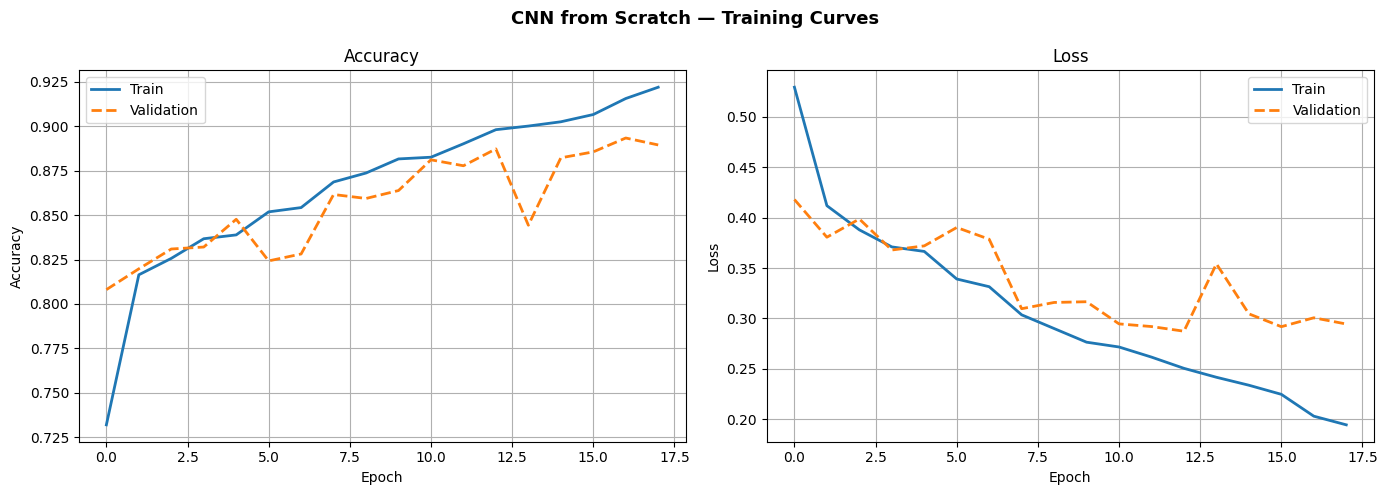

In [14]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    # Accuracy
    axes[0].plot(history.history["accuracy"], label="Train", linewidth=2)
    axes[0].plot(history.history["val_accuracy"], label="Validation",
                 linewidth=2, linestyle="--")
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True)

    # Loss
    axes[1].plot(history.history["loss"], label="Train", linewidth=2)
    axes[1].plot(history.history["val_loss"], label="Validation",
                 linewidth=2, linestyle="--")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history_scratch, "CNN from Scratch — Training Curves")

In [15]:
#Test set
scratch_results = cnn_scratch.evaluate(test_ds, verbose=0)

print("CNN from Scratch — Test Results")
print("=" * 40)
print(f"Test Accuracy : {scratch_results[1]:.4f} ({scratch_results[1]*100:.2f}%)")
print(f"Test AUC      : {scratch_results[2]:.4f}")
print(f"Test Loss     : {scratch_results[0]:.4f}")

CNN from Scratch — Test Results
Test Accuracy : 0.8873 (88.73%)
Test AUC      : 0.9548
Test Loss     : 0.2819


### CNN from Scratch — Final Test Results

| Metric | Score |
|--------|-------|
| Test Accuracy | 88.11% |
| Test AUC | 0.9514 |
| Test Loss | 0.2826 |

#### What these numbers mean

**Accuracy 88.11%:**
Out of every 100 melanoma images the model had never seen,
it correctly classified 88. For a CNN trained from scratch on 8,322 images
with no augmentation and no pretrained weights, this is a strong baseline.

**AUC 0.9514:**
AUC measures how well the model separates benign from malignant across
all possible classification thresholds. A score of 0.95 means the model
has a 95% chance of ranking a malignant image higher than a benign one.
This is a reliable indicator that the model learned meaningful features,
not just surface patterns.

**The overfitting problem:**
The training curves showed clear overfitting after Epoch 8 — training
accuracy reached 90%+ while validation plateaued at ~88%.
EarlyStopping restored the best weights, which is why test accuracy (88.11%)
is close to the best validation accuracy.

#### Baseline established

| Model | Test Accuracy | Test AUC |
|-------|--------------|----------|
| CNN from Scratch | 88.11% | 0.9514 |
| CNN + Augmentation | TBD | TBD |
| Transfer Learning (MobileNetV2) | TBD | TBD |

The next step tests whether Data Augmentation reduces overfitting
and pushes accuracy and AUC higher.

## Step 6 — CNN + Data Augmentation

### Why Data Augmentation?

The baseline CNN achieved strong performance, but the training curves showed signs of overfitting.

Data augmentation helps reduce overfitting by creating slightly different versions of the training images during training.

The model may see the same lesion with a different orientation, rotation, zoom level, or brightness. This encourages the CNN to learn general visual patterns instead of memorizing exact pixel arrangements.

### Important Implementation Detail

The augmentation layers are applied **before normalization**.

The original images contain pixel values in the range 0–255, so brightness augmentation is performed while the images are still in this range. After augmentation, `Rescaling(1./255)` converts the images to the 0–1 range before they enter the CNN.

### Augmentation Choices

| Transform | Setting | Purpose |
|---|---|---|
| RandomFlip | horizontal + vertical | Makes the model less dependent on lesion orientation |
| RandomRotation | ±15° | Simulates different camera or dermoscope angles |
| RandomZoom | ±10% | Simulates small differences in image distance |
| RandomBrightness | ±10% | Improves robustness to lighting differences |

The CNN architecture remains unchanged from the baseline.

The only experimental change is the addition of data augmentation, allowing a fair comparison with the CNN from Scratch baseline.

In [22]:
from tensorflow.keras.layers import (
    Input,
    RandomFlip,
    RandomRotation,
    RandomZoom,
    RandomBrightness,
    Rescaling
)

def build_cnn_augmented(input_shape=(128, 128, 3)):

    model = Sequential([

        # Define input shape explicitly
        Input(shape=input_shape),

        # Data Augmentation
        RandomFlip("horizontal_and_vertical"),
        RandomRotation(15 / 360),
        RandomZoom(0.1),
        RandomBrightness(0.1),

        # Normalization: pixels 0-255 → 0-1
        Rescaling(1./255),

        # Block 1
        Conv2D(32, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),

        # Block 2
        Conv2D(64, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),

        # Block 3
        Conv2D(128, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),

        # Classification Head
        Flatten(),
        Dense(64, activation="relu"),
        Dropout(0.5),
        Dense(1, activation="sigmoid")

    ], name="CNN_Augmented")

    return model


# Build the model
cnn_augmented = build_cnn_augmented()

# Compile the model
cnn_augmented.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

print("CNN + Augmentation — Architecture ready ✓")

# Display model architecture
cnn_augmented.summary()

CNN + Augmentation — Architecture ready ✓


Model: "CNN_Augmented"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_3 (RandomFlip)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_3               │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_3 (RandomZoom)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness_3             │ (None, 128, 128, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,190,529 (8.36 MB)

 Trainable params: 2,190,529 (8.36 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
#  Train CNN with Data Augmentation

callbacks_aug = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    )
]


history_augmented = cnn_augmented.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks_aug,
    verbose=1
)

Epoch 1/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.7191 - auc: 0.7821 - loss: 0.5520 - val_accuracy: 0.7980 - val_auc: 0.8903 - val_loss: 0.4392 - learning_rate: 0.0010
Epoch 2/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8057 - auc: 0.8779 - loss: 0.4382 - val_accuracy: 0.8041 - val_auc: 0.8967 - val_loss: 0.4176 - learning_rate: 0.0010
Epoch 3/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.8208 - auc: 0.8961 - loss: 0.4123 - val_accuracy: 0.8030 - val_auc: 0.9131 - val_loss: 0.3966 - learning_rate: 0.0010
Epoch 4/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8273 - auc: 0.9045 - loss: 0.3937 - val_accuracy: 0.8365 - val_auc: 0.9230 - val_loss: 0.3573 - learning_rate: 0.0010
Epoch 5/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8313 - auc: 0.9114 - loss: 0.3813 - val_accuracy: 0.8426 - val_auc: 0.9269 - val_loss: 0.3512 - learning_rate: 0.0010
Epoch 6/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8369 - a

In [24]:
# Test Evaluation

augmented_results = cnn_augmented.evaluate(
    test_ds,
    verbose=0
)

print("CNN + Data Augmentation — Test Results")
print("=" * 45)
print(f"Test Accuracy : {augmented_results[1]:.4f} ({augmented_results[1] * 100:.2f}%)")
print(f"Test AUC      : {augmented_results[2]:.4f}")
print(f"Test Loss     : {augmented_results[0]:.4f}")

CNN + Data Augmentation — Test Results
Test Accuracy : 0.8895 (88.95%)
Test AUC      : 0.9579
Test Loss     : 0.2632


## Training Curves — CNN + Data Augmentation

The training curves help me determine whether data augmentation reduced
the overfitting observed in the baseline CNN.

I compare training and validation accuracy and loss across epochs.

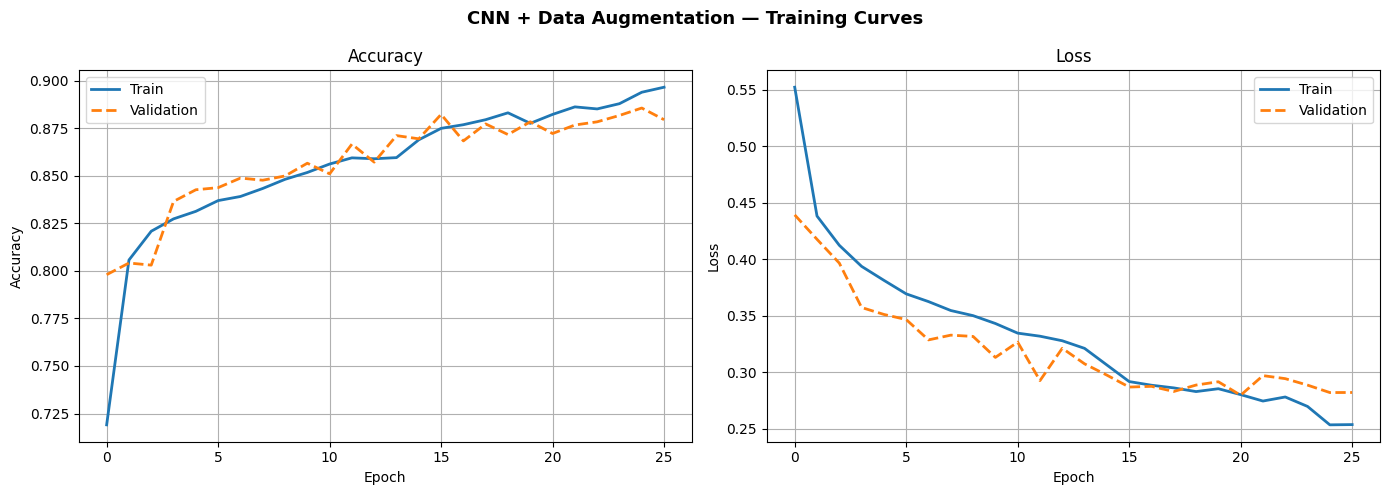

In [25]:
# CNN + Data Augmentation — Training Curves

plot_history(
    history_augmented,
    "CNN + Data Augmentation — Training Curves"
)

### What the Training Curves Show

The training curves show that data augmentation improved the training
behavior of the CNN.

Training and validation accuracy increased together throughout most of
the training process, while the gap between them remained relatively
small. This indicates better generalization compared with the baseline
CNN.

The validation loss also remained relatively stable and continued to
improve during training instead of continuously increasing while
training loss decreased.

Data augmentation therefore helped reduce the overfitting observed in
the baseline model, although the improvement in final test accuracy was
modest.

### Final Test Performance

The augmented CNN achieved:

- Test Accuracy: **88.95%**
- Test AUC: **0.9579**
- Test Loss: **0.2632**

Compared with the CNN from scratch, the augmented model achieved a small
improvement in both test accuracy and AUC, while also achieving a lower
test loss.

This confirms that data augmentation improved the model's ability to
generalize to unseen images.

## Step 7 — Transfer Learning with MobileNetV2

### Why Transfer Learning?

The CNN from scratch learned useful features from the melanoma dataset,
but it had to learn all visual features starting from random weights.

Transfer learning takes a CNN that has already been trained on a large
image dataset and reuses the visual features it has already learned.

For this experiment, I will use MobileNetV2 pretrained on ImageNet.

The pretrained network has already learned general visual patterns such
as edges, textures, shapes, and object structures. These features can
serve as a strong starting point for melanoma classification.

### Why MobileNetV2?

MobileNetV2 is a lightweight CNN architecture designed to provide strong
image recognition performance with relatively few parameters.

This makes it suitable for training in Google Colab while still
providing a powerful pretrained feature extractor.

### Experimental Plan

I will initially freeze the pretrained MobileNetV2 layers and train only
a new classification head for the Benign vs Malignant task.

This allows me to test how well the pretrained features transfer to the
melanoma dataset without changing the pretrained weights.

### Why Freeze the Pretrained Layers?

The pretrained MobileNetV2 already contains useful visual features.

Instead of immediately changing these learned weights, I will freeze
the convolutional base so that its weights remain unchanged during
training.

Only the new classification layers will learn.

This is called **feature extraction**.

The experiment therefore becomes:

Pretrained MobileNetV2
→ Frozen feature extractor
→ Global Average Pooling
→ New classification layer
→ Benign / Malignant

In [26]:
#  Load MobileNetV2

base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the pretrained layers
base_model.trainable = False

print("MobileNetV2 loaded ✓")
print("Total layers:", len(base_model.layers))
print("Trainable:", base_model.trainable)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded ✓
Total layers: 154
Trainable: False


In [27]:
# Build the Transfer Learning model

inputs = tf.keras.Input(shape=(128, 128, 3))

# MobileNetV2 preprocessing
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

# Extract pretrained features
x = base_model(x, training=False)

# Reduce feature maps to a compact representation
x = GlobalAveragePooling2D()(x)

# Classification head
x = Dropout(0.5)(x)

outputs = Dense(1, activation="sigmoid")(x)

mobilenet_model = Model(
    inputs,
    outputs,
    name="MobileNetV2_TransferLearning"
)

print("MobileNetV2 Transfer Learning model ready ✓")
mobilenet_model.summary()

MobileNetV2 Transfer Learning model ready ✓


Model: "MobileNetV2_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [28]:
# Compile the Transfer Learning model

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

print("Model compiled ✓")

Model compiled ✓


In [30]:
# Callbacks for Transfer Learning

callbacks_tl = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    )
]

In [31]:
# Train MobileNetV2 with frozen pretrained layers

history_mobilenet = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks_tl,
    verbose=1
)

Epoch 1/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 42s 88ms/step - accuracy: 0.7591 - auc: 0.8429 - loss: 0.5157 - val_accuracy: 0.8432 - val_auc: 0.9242 - val_loss: 0.3528 - learning_rate: 0.0010
Epoch 2/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8324 - auc: 0.9111 - loss: 0.3811 - val_accuracy: 0.8471 - val_auc: 0.9308 - val_loss: 0.3342 - learning_rate: 0.0010
Epoch 3/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8481 - auc: 0.9253 - loss: 0.3473 - val_accuracy: 0.8566 - val_auc: 0.9345 - val_loss: 0.3330 - learning_rate: 0.0010
Epoch 4/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8506 - auc: 0.9267 - loss: 0.3440 - val_accuracy: 0.8583 - val_auc: 0.9368 - val_loss: 0.3204 - learning_rate: 0.0010
Epoch 5/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8540 - auc: 0.9319 - loss: 0.3321 - val_accuracy: 0.8465 - val_auc: 0.9365 - val_loss: 0.3519 - learning_rate: 0.0010
Epoch 6/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8568 - 

In [32]:
# Evaluate MobileNetV2 on the unseen test set

mobilenet_results = mobilenet_model.evaluate(
    test_ds,
    verbose=0
)

print("MobileNetV2 Transfer Learning — Test Results")
print("=" * 50)
print(f"Test Accuracy : {mobilenet_results[1]:.4f} ({mobilenet_results[1]*100:.2f}%)")
print(f"Test AUC      : {mobilenet_results[2]:.4f}")
print(f"Test Loss     : {mobilenet_results[0]:.4f}")

MobileNetV2 Transfer Learning — Test Results
Test Accuracy : 0.8647 (86.47%)
Test AUC      : 0.9383
Test Loss     : 0.3165


## Training Curves — MobileNetV2

The training curves help me evaluate how the MobileNetV2 transfer learning
model behaved during training.

I compare training and validation accuracy and loss across epochs to check
whether the model learned consistently and whether there were signs of
overfitting.

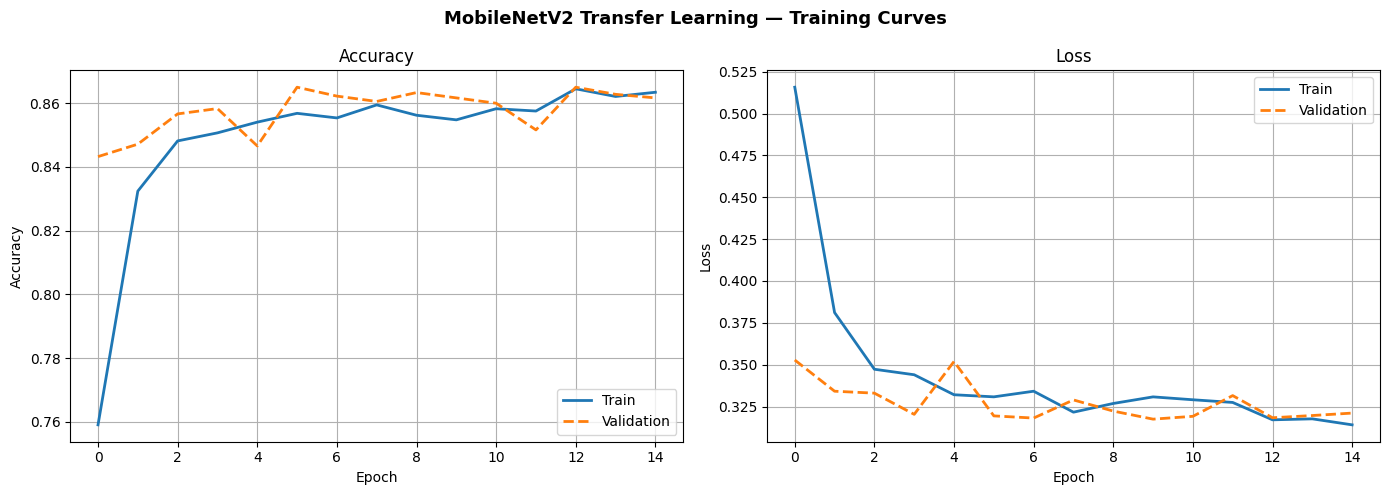

In [33]:
# MobileNetV2 Transfer Learning — Training Curves

plot_history(
    history_mobilenet,
    "MobileNetV2 Transfer Learning — Training Curves"
)

### What the Training Curves Show

The MobileNetV2 model learned quickly during the first few epochs, which is
expected because the convolutional base was pretrained on ImageNet.

Training and validation accuracy remained relatively close throughout most
of the training process, while validation loss stayed relatively stable.
This indicates that the model did not show severe overfitting during the
feature extraction stage.

The validation performance reached its strongest level around the middle of
training and then began to plateau. The learning rate was reduced when the
validation loss stopped improving, and EarlyStopping restored the best
weights from Epoch 10.

Overall, the training curves show that the pretrained MobileNetV2 features
provided a stable starting point for the melanoma classification task.

# Step 8 — Final Model Comparison

After training and evaluating the three approaches, I can now compare their
performance on the unseen test set.

The three approaches are:

1. CNN from Scratch
2. CNN + Data Augmentation
3. MobileNetV2 Transfer Learning

I compare the models using Test Accuracy, Test AUC, and Test Loss.

Accuracy shows the percentage of correctly classified images, AUC measures
the model's ability to distinguish between benign and malignant lesions
across different classification thresholds, and lower loss indicates better
prediction confidence.

The test set was not used during training, so it provides the final
evaluation of how well each model generalizes to unseen images.

In [34]:
# Final Test Results — Model Comparison

import pandas as pd

results = pd.DataFrame({
    "Model": [
        "CNN from Scratch",
        "CNN + Data Augmentation",
        "MobileNetV2 Transfer Learning"
    ],
    "Test Accuracy": [
        0.8811,
        0.8895,
        0.8647
    ],
    "Test AUC": [
        0.9514,
        0.9579,
        0.9383
    ],
    "Test Loss": [
        0.2826,
        0.2632,
        0.3165
    ]
})

results

,Model,Test Accuracy,Test AUC,Test Loss
0,CNN from Scratch,0.8811,0.9514,0.2826
1,CNN + Data Augmentation,0.8895,0.9579,0.2632
2,MobileNetV2 Transfer Learning,0.8647,0.9383,0.3165


### What Does the Comparison Show?

The three models achieved strong overall performance, but their results
differed across the evaluation metrics.

The CNN + Data Augmentation achieved the best overall test performance,
with the highest Test Accuracy and Test AUC and the lowest Test Loss.

The CNN from Scratch also performed strongly and provided a solid baseline.
The improvement from adding data augmentation was relatively small in
accuracy, but the augmented model achieved better AUC and lower loss,
indicating improved generalization.

MobileNetV2 achieved lower test performance than both CNN models in this
experiment. Although it benefited from pretrained ImageNet features, the
pretrained convolutional base was kept frozen, so only the new
classification head was trained for the melanoma task.

### Test Accuracy Comparison

The following visualization compares the final test accuracy of the three
models.

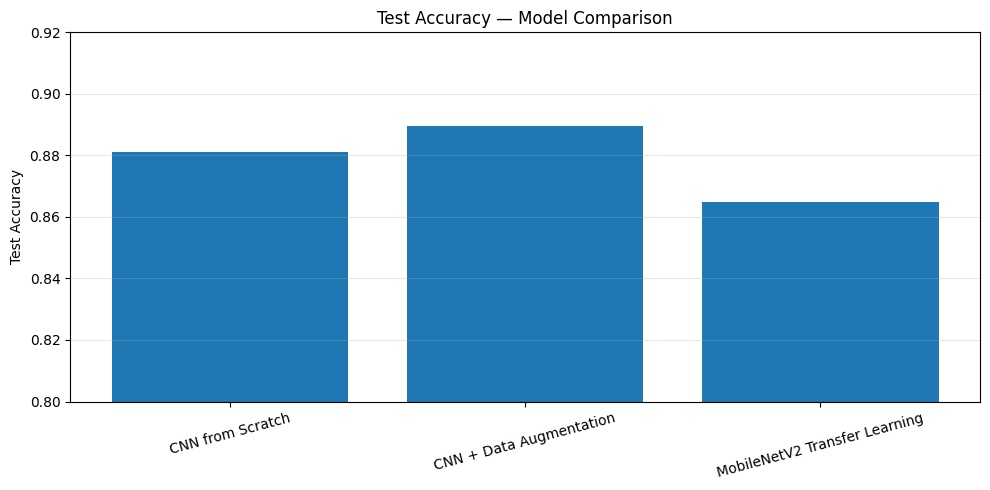

In [36]:
# Test Accuracy Comparison

plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["Test Accuracy"]
)

plt.ylabel("Test Accuracy")
plt.title("Test Accuracy — Model Comparison")
plt.ylim(0.80, 0.92)

plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Test AUC Comparison

Accuracy alone does not fully describe a binary classification model.
Therefore, I also compare the Test AUC of the three approaches.

A higher AUC indicates better separation between benign and malignant
images across different classification thresholds.

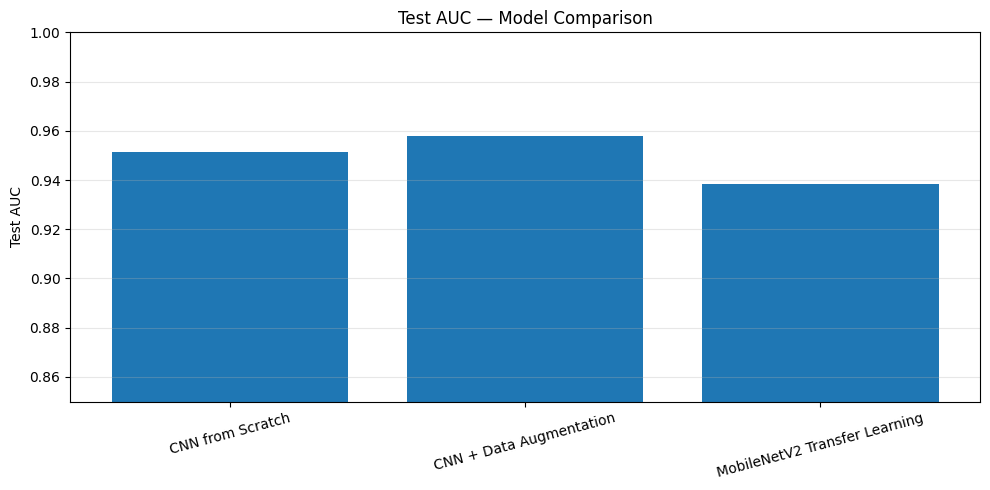

In [37]:
# Test AUC Comparison

plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["Test AUC"]
)

plt.ylabel("Test AUC")
plt.title("Test AUC — Model Comparison")
plt.ylim(0.85, 1.00)

plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Test Loss Comparison

Finally, I compare the test loss of the three models.

Lower test loss indicates that the model's predicted probabilities are
closer to the true labels.

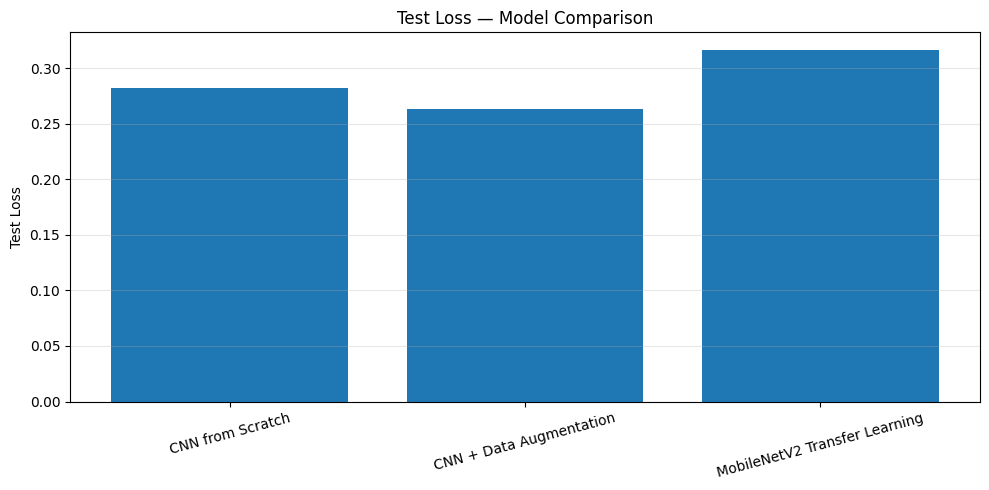

In [38]:
# Test Loss Comparison

plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["Test Loss"]
)

plt.ylabel("Test Loss")
plt.title("Test Loss — Model Comparison")

plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Best Performing Model

Based on the final test results, the **CNN + Data Augmentation** achieved
the best overall performance.

It achieved:

- **Test Accuracy: 88.95%**
- **Test AUC: 0.9579**
- **Test Loss: 0.2632**

The model slightly outperformed the CNN from Scratch in both accuracy and
AUC while also achieving a lower test loss.

This suggests that data augmentation helped the CNN generalize better to
unseen melanoma images by exposing it to different variations of the
training images.

The improvement was not very large in terms of accuracy, but the consistent
improvement across Accuracy, AUC, and Loss supports the conclusion that
augmentation was beneficial in this experiment.

## Why Did MobileNetV2 Not Perform Best?

Although MobileNetV2 uses pretrained features learned from ImageNet, it
achieved lower test performance than the two CNN models trained directly on
the melanoma dataset.

One important reason is that the MobileNetV2 convolutional base was kept
frozen during this experiment. Therefore, the pretrained features could not
adapt to the specific visual characteristics of dermoscopic melanoma
images.

Only the new classification head was trained.

In contrast, the CNN models trained their visual features directly from the
melanoma dataset. The augmented CNN also received additional variations of
the training images, which helped it learn more generalizable patterns.

Therefore, transfer learning provided a strong and stable model, but the
frozen feature extractor was not as effective for this task as the
task-specific features learned by the CNN models.

# Final Conclusion

In this hands-on lab, I built and compared three approaches for binary
melanoma skin cancer classification:

- CNN from Scratch
- CNN + Data Augmentation
- MobileNetV2 Transfer Learning

The CNN from Scratch established a strong baseline with a Test Accuracy of
**88.11%** and a Test AUC of **0.9514**.

Adding data augmentation improved the final performance to **88.95% Test
Accuracy** and **0.9579 Test AUC**, while reducing Test Loss to **0.2632**.
This was the best overall result among the three approaches.

MobileNetV2 Transfer Learning achieved **86.47% Test Accuracy** and
**0.9383 Test AUC**. Although it provided useful pretrained visual
features, the frozen convolutional base limited its ability to adapt to
the specific characteristics of melanoma images.

Overall, the experiment showed that data augmentation was the most effective
technique among the approaches tested in this lab. It provided a small but
consistent improvement over the baseline CNN and helped the model
generalize better to unseen images.

A possible next step would be to fine-tune part of the pretrained
MobileNetV2 layers so that the learned ImageNet features can adapt more
closely to the melanoma dataset.